In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# lode data

In [203]:
df = pd.read_csv('data/laptopData.csv')
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


# Data Exploration

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [205]:
df.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


<Axes: xlabel='Company'>

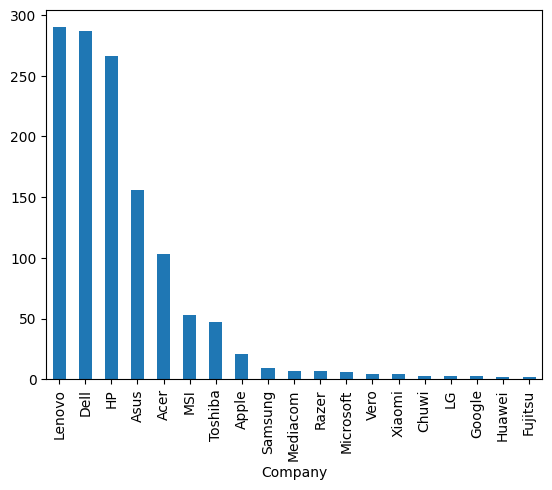

In [206]:
df['Company'].value_counts().plot.bar()

<Axes: xlabel='OpSys'>

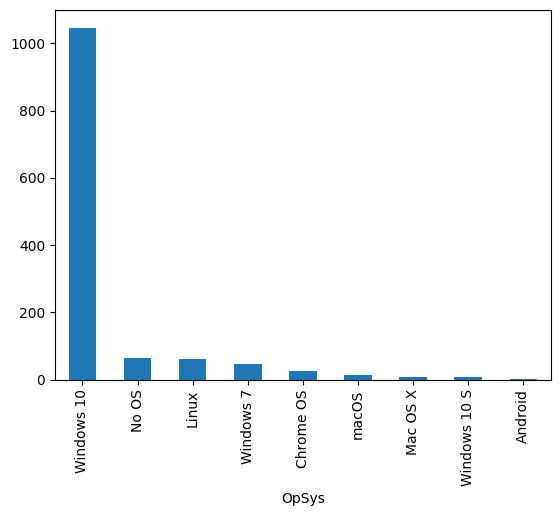

In [207]:
df['OpSys'].value_counts().plot.bar()

In [208]:
df.columns = df.columns.str.strip()

In [209]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

# Feature engineering

## null values

In [210]:
# see the null values 
df.isnull().sum()

Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [211]:
# dlete a row if all the col is nan
df.dropna(how='all',inplace=True)

In [212]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [213]:
#drop col "Unnamed: 0" becuse it is the index 
df = df.drop("Unnamed: 0", axis=1)
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


# Inches col

In [214]:
# Convert "Inches" from object to float
df.Inches.unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [215]:
df = df[df["Inches"] != '?']

In [216]:
#df.Inches.unique()
df["Inches"] = df["Inches"].astype(float)

C:\Users\admin\AppData\Local\Temp\ipykernel_8548\2832929533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Inches"] = df["Inches"].astype(float)


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1272 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1272 non-null   object 
 1   TypeName          1272 non-null   object 
 2   Inches            1272 non-null   float64
 3   ScreenResolution  1272 non-null   object 
 4   Cpu               1272 non-null   object 
 5   Ram               1272 non-null   object 
 6   Memory            1272 non-null   object 
 7   Gpu               1272 non-null   object 
 8   OpSys             1272 non-null   object 
 9   Weight            1272 non-null   object 
 10  Price             1272 non-null   float64
dtypes: float64(2), object(9)
memory usage: 119.2+ KB


# Ram col

In [218]:
# Remove GB from "Ram" and convert to int
#df.Ram.unique()
df["Ram"] = df["Ram"].str.replace("GB", "").astype(int)

C:\Users\admin\AppData\Local\Temp\ipykernel_8548\1877807868.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ram"] = df["Ram"].str.replace("GB", "").astype(int)


# Weight col

In [219]:
# Remove 'kg' from Weight and convert to float
#df.Weight.unique()
#remove ? ferom Weight
df = df[df["Weight"] != '?']
df["Weight"] = df["Weight"].str.replace("kg", "").astype(float)

In [220]:
df.dtypes

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price               float64
dtype: object

## Company col

In [221]:
#unique value
df.Company.unique()
#we can see that ther is 19 unique value 
#['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI','Microsoft', 'Toshiba',
#'Huawei', 'Xiaomi', 'Vero', 'Razer','Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG']

array(['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI',
       'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer',
       'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG'], dtype=object)

## TypeName col

In [222]:
#unique value
df.TypeName.unique()
#ther is 6 type 
#['Ultrabook', 'Notebook', 'Gaming', '2 in 1 Convertible','Workstation', 'Netbook']

array(['Ultrabook', 'Notebook', 'Gaming', '2 in 1 Convertible',
       'Workstation', 'Netbook'], dtype=object)

## ScreenResolution col

In [223]:
#unique value
df.ScreenResolution.unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', '1600x900',
       'IPS Panel 4K Ultra HD 3840x2160', '4K Ultra HD 3840x2160',
       'Touchscreen 1366x768', 'Touchscreen 2560x1440',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel Quad HD+ 3200x1800',
       'IPS Panel Qua

In [260]:
# take the Resolution Width and Height
df['Resolution_Width'] = df['ScreenResolution'].str.extract(r'(\d+)x')[0].astype(int)
df['Resolution_Height'] = df['ScreenResolution'].str.extract(r'x(\d+)')[0].astype(int)
print(df['Resolution_Width'].unique())
print(df['Resolution_Height'].unique())

[2560 1440 1920 2880 1366 2304 3200 2256 3840 2160 1600 2736 2400]
[1600  900 1080 1800  768 1440 1504 2160 1824 1200]


In [263]:
df['IsTouch'] = df['ScreenResolution'].str.contains('Touchscreen', na=False)
df['IsTouch'].unique()

array([False,  True])

In [265]:
#deop the ScreenResolution colm
df = df.drop("ScreenResolution", axis=1)

## Cpu col

In [224]:
#unique value
df['Cpu'].unique()
# ther is so meany tupes of CPUs 
#put we can take some meningfull info tjoe the tipe of CPU and the GHz whech i thing will effict the Price 
#and it is semelar in all 3 CPU companes 

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Core i5 7300HQ 2.5GHz',
       'AMD E-Series E2-9000e 1.5GHz', 'Intel Core i5 1.6GHz',
       'Intel Core i7 8650U 1.9GHz', 'Intel Atom x5-Z8300 1.44GHz',
       'AMD E-Series E2-6110 1.5GHz', 'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Celeron Dual Core N3060 1.6GHz', 'Intel Core i5 1.3GHz',
       'AMD FX 9830P 3GHz', '

In [226]:
# creat a new colm called Cpu_brand that contanes the CPU Brands ['Intel', 'AMD', 'Samsung']
df["Cpu_brand"] = df["Cpu"].str.split().str[0]
df.Cpu_brand.unique()

array(['Intel', 'AMD', 'Samsung'], dtype=object)

In [227]:
#creat anew col called cpu_GHz that have the Ghz value of the CPU only
df["cpu_GHz"] = df["Cpu"].str.split().str[-1]
#remove the GHz from the colm so we can change the data type to float 
df["cpu_GHz"] = df["cpu_GHz"].str.replace("GHz", "", regex=False).astype(float)
df.cpu_GHz.unique()

array([2.3 , 1.8 , 2.5 , 2.7 , 3.1 , 3.  , 2.2 , 1.6 , 2.  , 2.8 , 1.2 ,
       2.9 , 2.4 , 1.5 , 1.9 , 1.44, 1.1 , 1.3 , 2.6 , 3.6 , 3.2 , 1.  ,
       2.1 , 0.9 , 1.92])

In [228]:
#drop Cpu colm
df = df.drop("Cpu", axis=1)
df

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_brand,cpu_GHz
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,2.3
1,Apple,Ultrabook,13.3,1440x900,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,1.8
2,HP,Notebook,15.6,Full HD 1920x1080,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,2.5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,2.7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,Intel,2.5
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,Intel,2.5
1300,Lenovo,Notebook,14.0,1366x768,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,Intel,1.6
1301,HP,Notebook,15.6,1366x768,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,Intel,2.5


## Memory col

In [229]:
#unique value
df.Memory.unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '128GB SSD +  1TB HDD', '256GB SSD +  256GB SSD',
       '64GB Flash Storage', '32GB Flash Storage', '256GB SSD +  1TB HDD',
       '256GB SSD +  2TB HDD', '32GB SSD', '2TB HDD', '64GB SSD',
       '1.0TB Hybrid', '512GB SSD +  1TB HDD', '1TB SSD',
       '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '?', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [230]:
#remove rows with ?
df = df[df["Memory"] != '?']

In [235]:
#we can 2 meingfall info from this colm 1- the storig with GB 2- the type of storig [SSD,HDD,Hybrid,Flash storage]
df["Memory_size"] = df["Memory"].str.split().str[0]
df.Memory_size.unique()

C:\Users\admin\AppData\Local\Temp\ipykernel_8548\1731095698.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Memory_size"] = df["Memory"].str.split().str[0]


array(['128GB', '256GB', '512GB', '500GB', '1TB', '64GB', '32GB', '2TB',
       '1.0TB', '16GB', '180GB', '240GB', '8GB', '508GB'], dtype=object)

In [237]:
#after observeing the Memory_size col it has GB and TB 
#so the pest is to convert TB to GB
# 1TB == 1000GB
df["Memory_size"] =df["Memory_size"].str.replace(".0", "")
df["Memory_size"] =df["Memory_size"].str.replace("TB", "000")
df["Memory_size"] =df["Memory_size"].str.replace("GB", "").astype(int)
df.Memory_size.unique()

C:\Users\admin\AppData\Local\Temp\ipykernel_8548\2056080075.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Memory_size"] =df["Memory_size"].str.replace(".0", "")
C:\Users\admin\AppData\Local\Temp\ipykernel_8548\2056080075.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Memory_size"] =df["Memory_size"].str.replace("TB", "000")
C:\Users\admin\AppData\Local\Temp\ipykernel_8548\2056080075.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

array([ 128,  256,  512,  500, 1000,   64,   32, 2000,   16,  180,  240,
          8,  508])

In [241]:
df["Memory_type"] = df["Memory"].str.split().str[1]
df.Memory_type.unique()

array(['SSD', 'Flash', 'HDD', 'Hybrid'], dtype=object)

In [239]:
#deop the Memory colm
df = df.drop("Memory", axis=1)
df

,Company,TypeName,Inches,ScreenResolution,Ram,Gpu,OpSys,Weight,Price,Cpu_brand,cpu_GHz,Memory_size,Memory_type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,2.3,128,SSD
1,Apple,Ultrabook,13.3,1440x900,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,1.8,128,Flash
2,HP,Notebook,15.6,Full HD 1920x1080,8,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,2.5,256,SSD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,2.7,512,SSD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,3.1,256,SSD
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,4,Intel HD Graphics 520,Windows 10,1.80,33992.6400,Intel,2.5,128,SSD
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,16,Intel HD Graphics 520,Windows 10,1.30,79866.7200,Intel,2.5,512,SSD
1300,Lenovo,Notebook,14.0,1366x768,2,Intel HD Graphics,Windows 10,1.50,12201.1200,Intel,1.6,64,Flash
1301,HP,Notebook,15.6,1366x768,6,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,Intel,2.5,1000,HDD


## Gpu col

In [252]:
df["Gpu"] = df["Gpu"].str.strip()

In [253]:
#unique value
df.Gpu.unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce 940MX', 'Nvidia GeForce GTX 1050', 'AMD Radeon R2',
       'AMD Radeon 530', 'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce GTX 1060',
       'Nvidia GeForce 150MX', 'Intel Iris Graphics 540',
       'AMD Radeon RX 580', 'Nvidia GeForce 920MX',
       'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Intel HD Graphics 400', 'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvidia GeForce 920M', 'AMD Radeon R7

In [254]:
#to clean the Gpu col i wall gorep it in meingfull way 
def extract_gpu_type(gpu):
    gpu = gpu.lower()

    if 'nvidia' in gpu:
        if 'rtx' in gpu:
            return 'Nvidia RTX'
        elif 'gtx' in gpu:
            return 'Nvidia GTX'
        elif 'mx' in gpu or 'geforce' in gpu:
            return 'Nvidia MX'
        elif 'quadro' in gpu:
            return 'Nvidia Quadro'
        else:
            return 'Nvidia Other'

    elif 'amd' in gpu:
        if 'radeon' in gpu:
            return 'AMD Radeon'
        elif 'firepro' in gpu:
            return 'AMD FirePro'
        else:
            return 'AMD Other'

    elif 'intel' in gpu:
        if 'iris' in gpu:
            return 'Intel Iris'
        elif 'uhd' in gpu:
            return 'Intel UHD'
        elif 'hd' in gpu:
            return 'Intel HD'
        else:
            return 'Intel Other'

    elif 'arm' in gpu:
        return 'ARM'

    else:
        return 'Unknown'
#df["Gpu_brand"] =df["Gpu"].str.split().str[0]
#df.Gpu_brand.unique()

In [256]:
df["Gpu_Type"] = df["Gpu"].apply(extract_gpu_type)
df.Gpu_Type.unique()

array(['Intel Iris', 'Intel HD', 'AMD Radeon', 'Nvidia MX', 'Intel UHD',
       'Nvidia GTX', 'AMD Other', 'Nvidia Quadro', 'AMD FirePro',
       'Intel Other', 'ARM'], dtype=object)

In [258]:
#deop the Gpu colm
df = df.drop("Gpu", axis=1)
df

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,Cpu_brand,cpu_GHz,Memory_size,Memory_type,Gpu_Type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,71378.6832,Intel,2.3,128,SSD,Intel Iris
1,Apple,Ultrabook,13.3,1440x900,8,macOS,1.34,47895.5232,Intel,1.8,128,Flash,Intel HD
2,HP,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,30636.0000,Intel,2.5,256,SSD,Intel HD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,135195.3360,Intel,2.7,512,SSD,AMD Radeon
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,96095.8080,Intel,3.1,256,SSD,Intel Iris
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,4,Windows 10,1.80,33992.6400,Intel,2.5,128,SSD,Intel HD
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,16,Windows 10,1.30,79866.7200,Intel,2.5,512,SSD,Intel HD
1300,Lenovo,Notebook,14.0,1366x768,2,Windows 10,1.50,12201.1200,Intel,1.6,64,Flash,Intel HD
1301,HP,Notebook,15.6,1366x768,6,Windows 10,2.19,40705.9200,Intel,2.5,1000,HDD,AMD Radeon


## OpSys col

In [61]:
#unique value
df.OpSys.unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux',
       'Windows 10 S', 'Chrome OS', 'Windows 7', 'Android'], dtype=object)

In [270]:
df.dtypes

Company               object
TypeName              object
Inches               float64
Ram                    int64
OpSys                 object
Weight               float64
Price                float64
Cpu_brand             object
cpu_GHz              float64
Memory_size            int64
Memory_type           object
Gpu_Type              object
Resolution_Width       int64
Resolution_Height      int64
IsTouch                 bool
dtype: object

<Axes: >

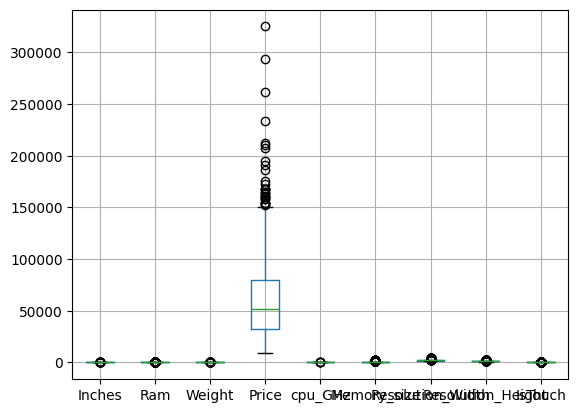

In [266]:
df.boxplot()

<Axes: >

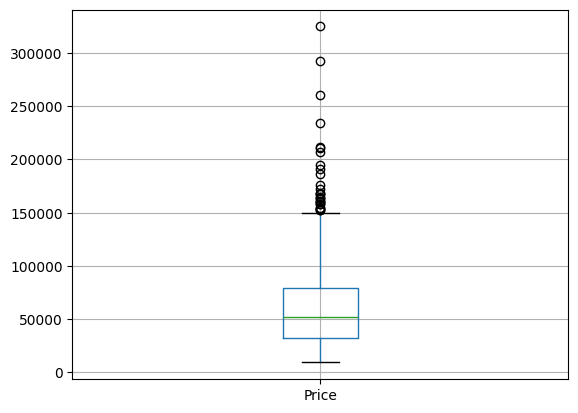

In [267]:
df.boxplot('Price')
#we can see that ther is some outlier in price 

# Removing Outliers from the Price Column

## using IQR Method 
if data is belw LL and above UL thein it is outlier

In [271]:
# Step 1: Calculate IQR
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define bounds
ll= Q1 - 1.5 * IQR
ul= Q3 + 1.5 * IQR

# Step 3: Filter the DataFrame
df = df[(df['Price'] >= ll) & (df['Price'] <= ul)]


<Axes: >

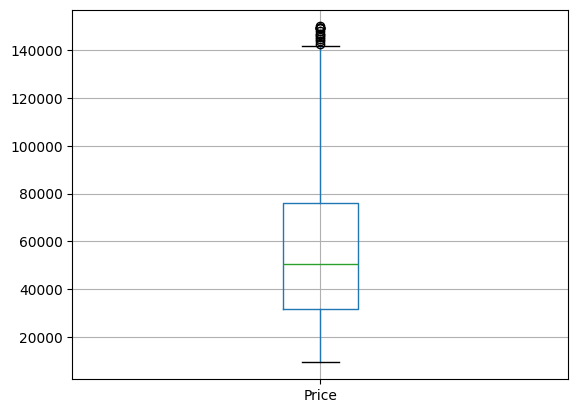

In [272]:
df.boxplot('Price')

# Categorical variable Encoding

In [ ]:
Company               object
TypeName              object

OpSys                 object

Cpu_brand             object

Memory_type           object
Gpu_Type              object

IsTouch                 bool
dtype: object

In [329]:
from sklearn.preprocessing import LabelEncoder
#Make a copy
df_encoded = df.copy()
df_encoded2 = df.copy()

In [336]:
#Label Encoding 
label_cols = ['Company', 'Cpu_brand', 'Gpu_Type','TypeName', 'Memory_type', 'OpSys']
le = LabelEncoder()
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [282]:
# One-Hot
one_hot_cols = ['TypeName', 'Memory_type', 'OpSys']
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)

In [331]:
df_encoded.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Cpu_brand,cpu_GHz,Memory_size,Memory_type,Gpu_Type,Resolution_Width,Resolution_Height,IsTouch
0,1,4,13.3,8,8,1.37,71378.6832,1,2.3,128,3,5,2560,1600,False
1,1,4,13.3,8,8,1.34,47895.5232,1,1.8,128,0,4,1440,900,False
2,7,3,15.6,8,4,1.86,30636.0000,1,2.5,256,3,4,1920,1080,False
3,1,4,15.4,16,8,1.83,135195.3360,1,2.7,512,3,2,2880,1800,False
4,1,4,13.3,8,8,1.37,96095.8080,1,3.1,256,3,5,2560,1600,False


In [332]:
df_encoded.dtypes

Company                int64
TypeName               int64
Inches               float64
Ram                    int64
OpSys                  int64
Weight               float64
Price                float64
Cpu_brand              int64
cpu_GHz              float64
Memory_size            int64
Memory_type            int64
Gpu_Type               int64
Resolution_Width       int64
Resolution_Height      int64
IsTouch                 bool
dtype: object

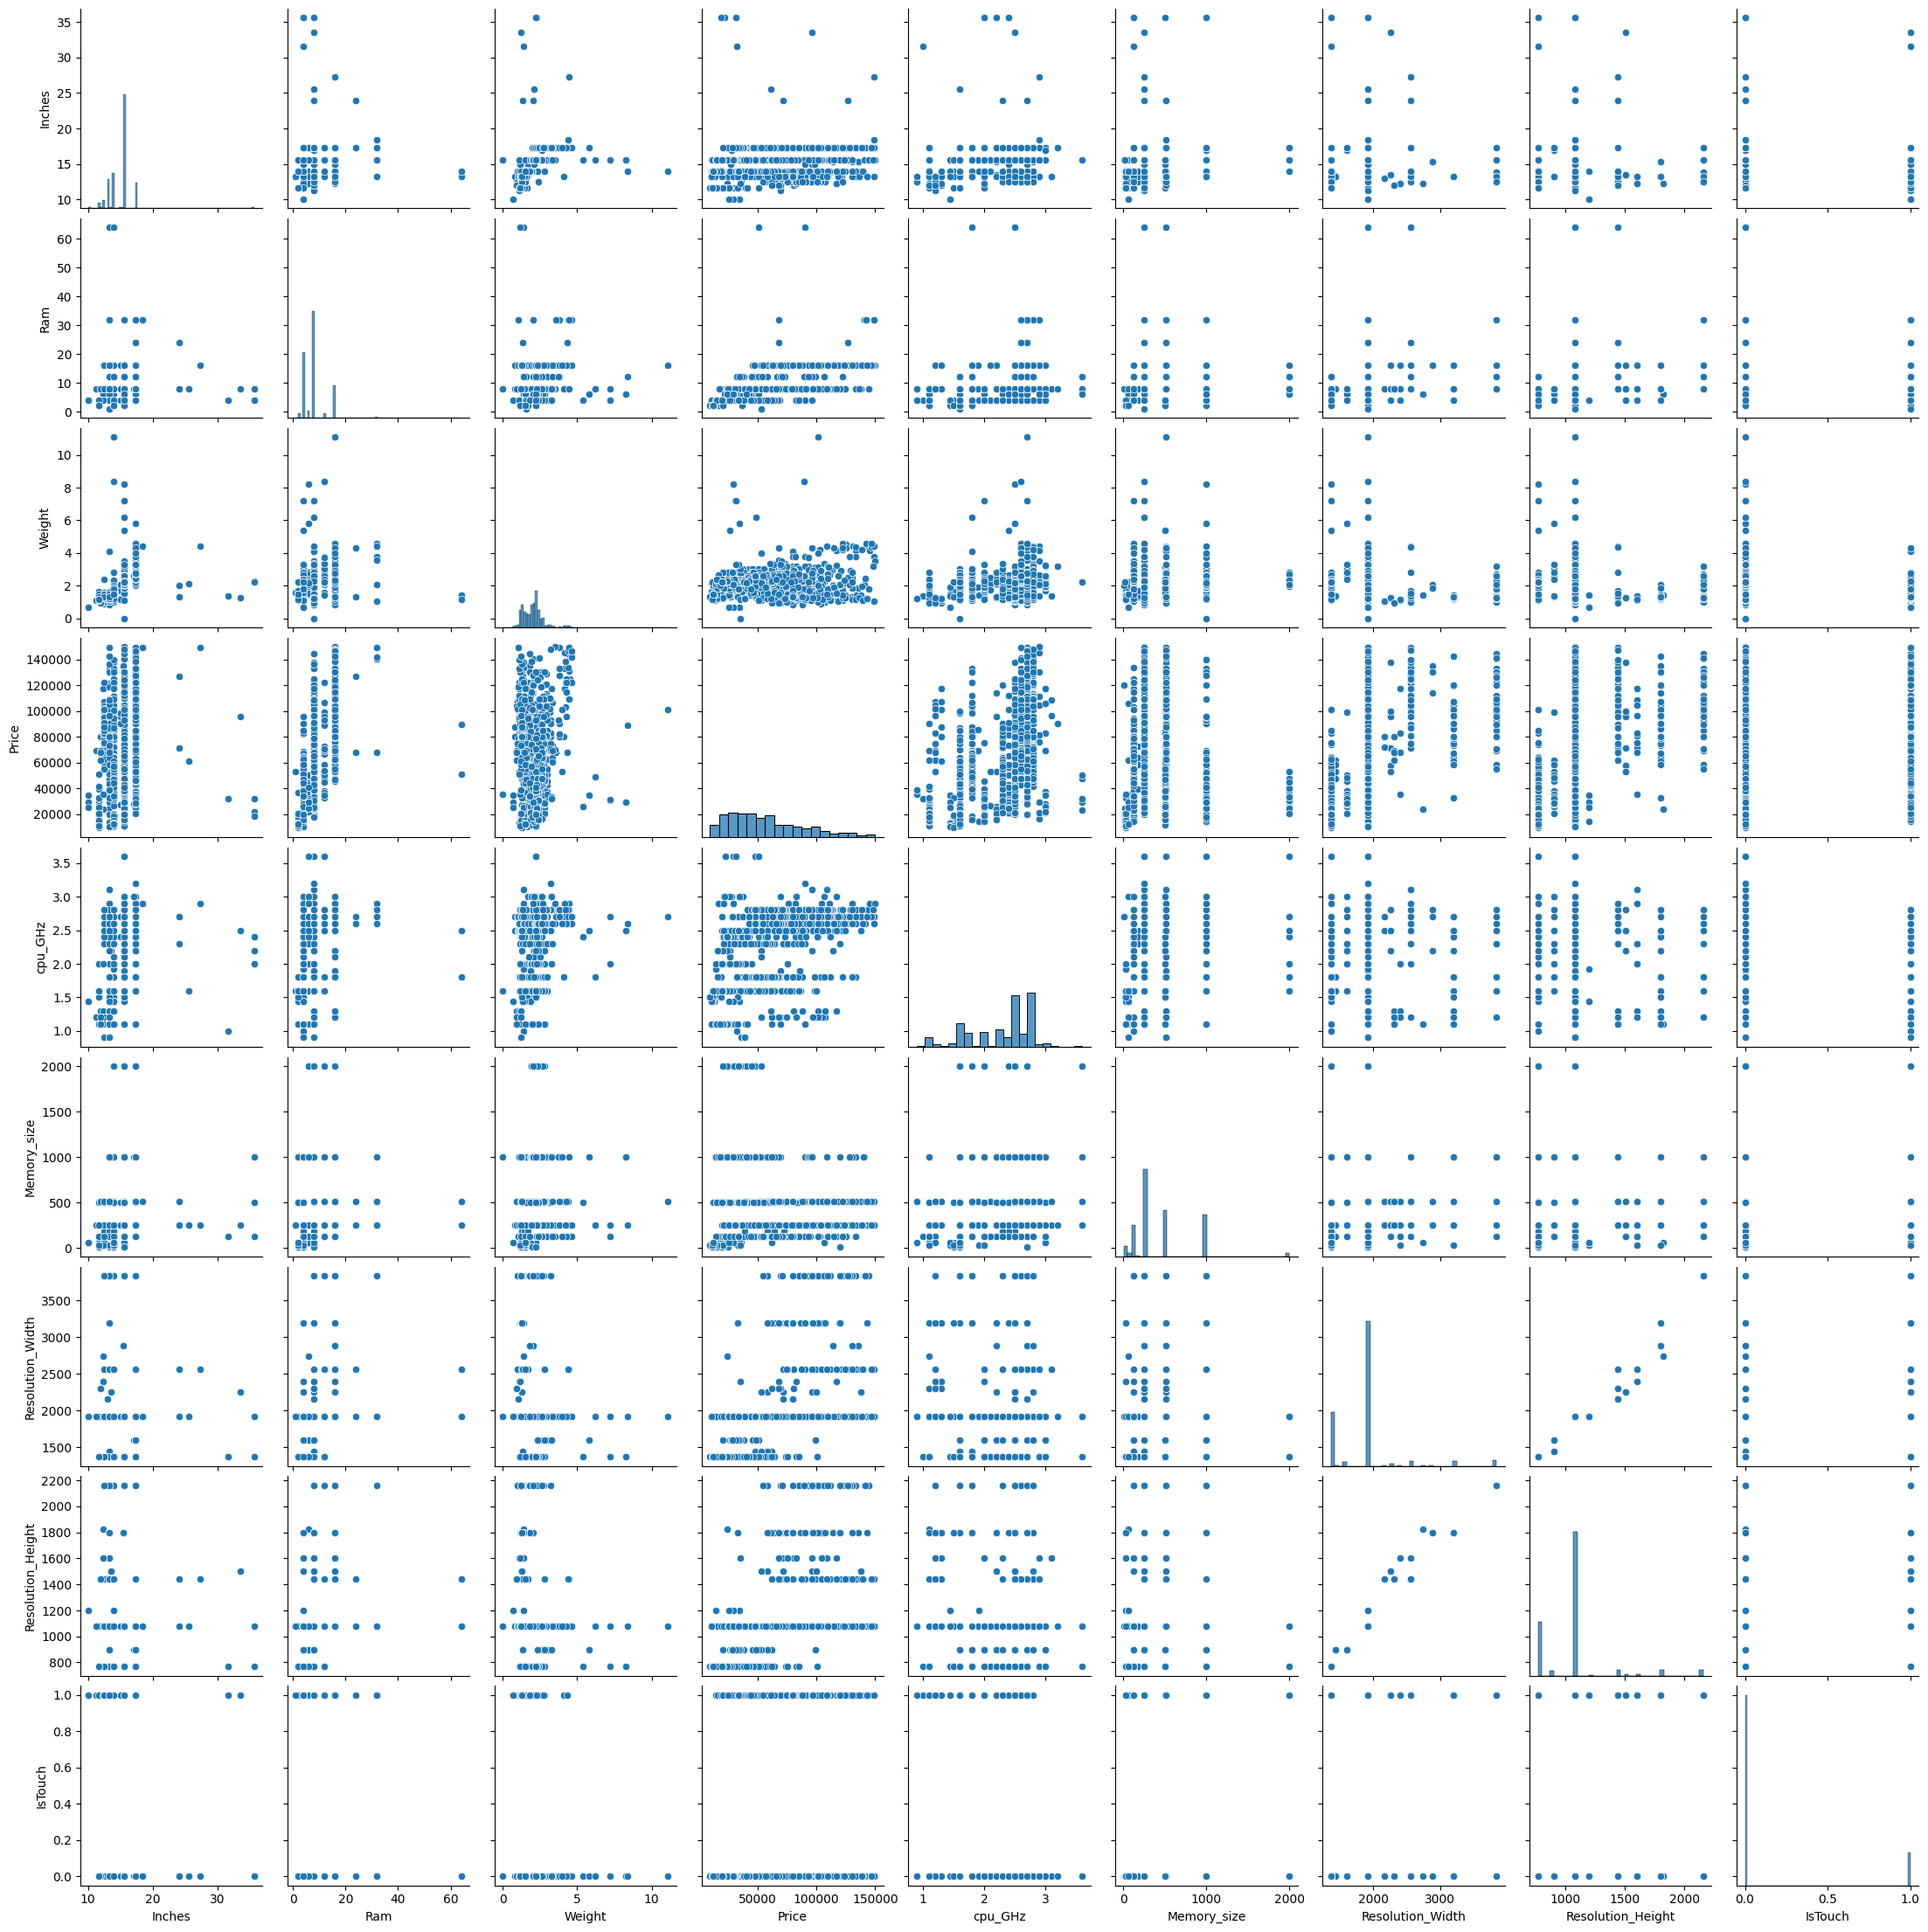

In [277]:
import seaborn as sns
sns.pairplot(df)
plt.show()

# Ml

In [318]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.linear_model import LinearRegression, Lasso,Ridge
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Train-test split

In [337]:
# Target column
y = df_encoded['Price']

# Feature columns (drop the target column)
X = df_encoded.drop('Price', axis=1)

In [338]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression model

In [339]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [340]:
#fit
y_pred = model.predict(X_test)

In [341]:
#Evaluate the model (metrics explained)
mae_l = mean_absolute_error(y_test, y_pred)
mse_l = mean_squared_error(y_test, y_pred)
rmse_l = np.sqrt(mse)
r2_l = r2_score(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Coefficients (slope): {model.coef_}")  # Will print all slopes
print(f"Intercept: {model.intercept_:.2f}")    # Scalar value

print(f"Mean Absolute Error (MAE): {mae_l:.2f}")
print(f"Mean Squared Error (MSE): {mse_l:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_l:.2f}")
print(f"R-squared (R2): {r2_l:.2f}")

--- Linear Regression Results ---
Coefficients (slope): [ 2.83328577e+02  1.22577669e+03 -6.84206584e+02  2.18505666e+03
  3.74801105e+03  5.41246808e+02  1.57709310e+04  1.43094337e+04
 -5.10875268e+00  5.13209883e+03  1.08576528e+03 -2.26216462e+01
  6.34651912e+01  9.71518092e+03]
Intercept: -63263.55
Mean Absolute Error (MAE): 14268.86
Mean Squared Error (MSE): 346171698.32
Root Mean Squared Error (RMSE): 17022.72
R-squared (R2): 0.68


## Polynomial Regression

In [342]:
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [343]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\n--- Polynomial Regression Results (Degree 2) ---")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")


--- Polynomial Regression Results (Degree 2) ---
Mean Absolute Error (MAE): 11646.22
Mean Squared Error (MSE): 239334657.06
Root Mean Squared Error (RMSE): 15470.44
R-squared (R2): 0.78


## Lasso Regression

In [344]:
model_lasso = Lasso(alpha=1.0)
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Lasso Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")



--- Lasso Regression Results ---
Mean Absolute Error (MAE): 14269.02
Mean Squared Error (MSE): 346158707.18
Root Mean Squared Error (RMSE): 18605.34
R-squared (R2): 0.68


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.539e+10, tolerance: 9.853e+07
  model = cd_fast.enet_coordinate_descent(


## Ridge Regression

In [345]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n--- Ridge Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")



--- Ridge Regression Results ---
Mean Absolute Error (MAE): 14271.94
Mean Squared Error (MSE): 346123816.48
Root Mean Squared Error (RMSE): 18604.40
R-squared (R2): 0.68


## Decision Tree Regressor

In [346]:
model_tree = DecisionTreeRegressor(random_state=42)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("\n--- Decision Tree Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae_tree:.2f}")
print(f"Mean Squared Error (MSE): {mse_tree:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tree:.2f}")
print(f"R-squared (R2): {r2_tree:.2f}")



--- Decision Tree Regressor Results ---
Mean Absolute Error (MAE): 12026.81
Mean Squared Error (MSE): 318221470.03
Root Mean Squared Error (RMSE): 17838.76
R-squared (R2): 0.71


## Random Forest Regressor

In [347]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")



--- Random Forest Regressor Results ---
Mean Absolute Error (MAE): 9251.38
Mean Squared Error (MSE): 184763985.06
Root Mean Squared Error (RMSE): 13592.79
R-squared (R2): 0.83


## SVM Regressor

In [348]:
# Scale the data for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

model_svr = SVR(kernel='rbf')
model_svr.fit(X_train_scaled, y_train_scaled)
y_pred_svr_scaled = model_svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1))

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\n--- Support Vector Regression (SVR) Results ---")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")



--- Support Vector Regression (SVR) Results ---
Mean Absolute Error (MAE): 10444.19
Mean Squared Error (MSE): 209990905.01
Root Mean Squared Error (RMSE): 14491.06
R-squared (R2): 0.81


# comparison between regression models

In [349]:
print(f"Linear Regression model R-squared (R2): {r2_l:.2f}")
print(f"Polynomial Regression R-squared (R2): {r2_poly:.2f}")
print(f"Lasso Regression R-squared (R2): {r2_lasso:.2f}")
print(f" Ridge Regression R-squared (R2): {r2_ridge:.2f}")
print(f"Decision Tree Regressor R-squared (R2): {r2_tree:.2f}")
print(f" Random Forest Regressor R-squared (R2): {r2_rf:.2f}")
print(f" SVM Regressor R-squared (R2): {r2_svr:.2f}")

Linear Regression model R-squared (R2): 0.68
Polynomial Regression R-squared (R2): 0.78
Lasso Regression R-squared (R2): 0.68
 Ridge Regression R-squared (R2): 0.68
Decision Tree Regressor R-squared (R2): 0.71
 Random Forest Regressor R-squared (R2): 0.83
 SVM Regressor R-squared (R2): 0.81
